# Projet : Filtrage de Kalman
_Auteur : ClapTrap – Objectif : Réaliser un filtre qui retrouve biais et angle d'un IMU en déplacement 1D(rot) pour lequel on dispose des mesures d'accélération et de gyroscopie_
_Date : 2026-04-03_
---


## 1. Liens avec le web

Regrouper ici tous les liens.

https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python/blob/04b2bea802321086effbd99402fc13c893d11110/10-Unscented-Kalman-Filter.ipynb

https://www.ferdinandpiette.com/blog/2011/04/exemple-dutilisation-du-filtre-de-kalman/



## 2. Installation et import des bibliothèques

Regrouper ici toutes les installations `pip` propres à Colab et tous les imports.

In [1]:
# import math
import matplotlib.pyplot as plt

from Test_Kalman_6 import Test_Kalman_6_Class_v2 as tk

## 3. Définition des paramètres globaux

Centraliser ici les constantes, chemins, et paramètres configurables.

In [2]:
# Paramètres globaux

simConfig = tk.SimulationConfig(
    totalTime=100,
    sampleSize=100,
    randomSeed=123,
    trueInitialAlpha=45.0,  # angle initial vrai (°)
    trueInitialAlphadot=0.0,  # vitesse angulaire initiale vraie (°/s)
    trueInitialBias=20.0,  # biais de vitesse angulaire vrai (°/s)
    measurementAccelNoiseStd=0.5,  # écart-type bruit accéléromètre
    measurementAlphadotNoiseStd=5.0,  # écart-type bruit gyroscope
    gravity=9.81,
    angleUnitIsDegree=True
)

# paramsRef = tk.UkfParams(
#     simConfig=simConfig,
#     supposedInitialAlpha=0.0,  # angle initial supposé (°)
#     supposedInitialAlphadot=0.0,  # vitesse angulaire initiale supposée (°/s)
#     supposedInitialBias=0.0,  # biais initial supposé (°/s)
#     processAlphaNoiseStd=0.1,  # => Q sur alpha
#     processAlphadotNoiseStd=5.0,  # => Q sur alphadot
#     processBiasNoiseStd=0.001,  # => Q sur biais
#     processInitialConfidenceStd=1000.0,
# )

paramsRef = tk.UkfParams(
    simConfig=simConfig,
    supposedInitialAlpha=30.0,  # angle initial supposé (°)
    supposedInitialAlphadot=0.0,  # vitesse angulaire initiale supposée (°/s)
    supposedInitialBias=0.0,  # biais initial supposé (°/s)
    processAlphaNoiseStd=0.1,  # => Q sur alpha
    processAlphadotNoiseStd=5.0,  # => Q sur alphadot
    processBiasNoiseStd=0.001,  # => Q sur biais
    processInitialConfidenceStd=1000.0,
)

# params_QBias01 = tk.UkfParams.fromBase(paramsRef, processBiasNoiseStd=0.1)


## 4. Définition des fonctions principales

Regrouper ici les fonctions réutilisables pour le traitement.

## 5. Exécution principale

Utiliser les fonctions définies pour produire les résultats.

In [3]:
# Génération du comportement vrai et des mesures bruitées
(TimeArray,
 TrueAlphaArray,
 TrueAlphadotArray,
 MeasuredAccelXArray,
 MeasuredAccelYArray,
 MeasuredAlphadotArray) = simConfig.generateTrueValuesAndMeasurements()

TimeStep : 1.0


In [4]:
# Création et configuration du filtre de Kalman
ukfModel = tk.UkfModel(simConfig)
runner = tk.UkfRunner()

# results = [
#     runner.run(ukfModel, paramsRef,
#                MeasuredAccelXArray, MeasuredAccelYArray, MeasuredAlphadotArray,
#                label="référence"),
#     runner.run(ukfModel, params_QBias01,
#                MeasuredAccelXArray, MeasuredAccelYArray, MeasuredAlphadotArray,
#                label="Q_bias=0.1"),
# ]



results = [
    runner.run(ukfModel, paramsRef,
               MeasuredAccelXArray, MeasuredAccelYArray, MeasuredAlphadotArray,
               label="processBiasNoiseStd=0.001"),
    runner.run(ukfModel, tk.UkfParams.fromBase(paramsRef, processBiasNoiseStd=0.01),
               MeasuredAccelXArray, MeasuredAccelYArray, MeasuredAlphadotArray,
               label="processBiasNoiseStd=0.01"),
    runner.run(ukfModel, tk.UkfParams.fromBase(paramsRef, processBiasNoiseStd=0.1),
               MeasuredAccelXArray, MeasuredAccelYArray, MeasuredAlphadotArray,
               label="processBiasNoiseStd=0.1"),
    runner.run(ukfModel, tk.UkfParams.fromBase(paramsRef, processBiasNoiseStd=1.0),
               MeasuredAccelXArray, MeasuredAccelYArray, MeasuredAlphadotArray,
               label="processBiasNoiseStd=1.0"),

]



## 6. Visualisation des résultats

Tracer les données ou les résultats principaux.

In [5]:
doRoll = True
# doRoll = False
if doRoll:
    TrueAlphaArray = tk.Modulo(-180., 360.0, TrueAlphaArray)
    for res in results:
        res.estimatedAlphaArray = tk.Modulo(-180., 360.0, res.estimatedAlphaArray)
        res.estimatedAlphadotArray = tk.Roll(-20., 20.0, res.estimatedAlphadotArray)
        res.estimatedBiasArray = tk.Roll(-20., 120.0, res.estimatedBiasArray)
    #
    # TrueAlphaArray = tk.Roll(-180., 360.0, TrueAlphaArray)
    # EstimatedAlphaArray = tk.AngleModulo360(EstimatedAlphaArray, -180., 180.0)
    # EstimatedAlphadotArray = tk.AngleModulo360(EstimatedAlphadotArray, -20., 20.0)
    # EstimatedBiasArray = tk.AngleModulo360(EstimatedBiasArray, -20., 120.0)

In [6]:
alphaMin = -200
alphaMax = 200
alphadotMin = -50
alphadotMax = 50
biasMin = -100
biasMax = 100
doClip = True
doClip = False

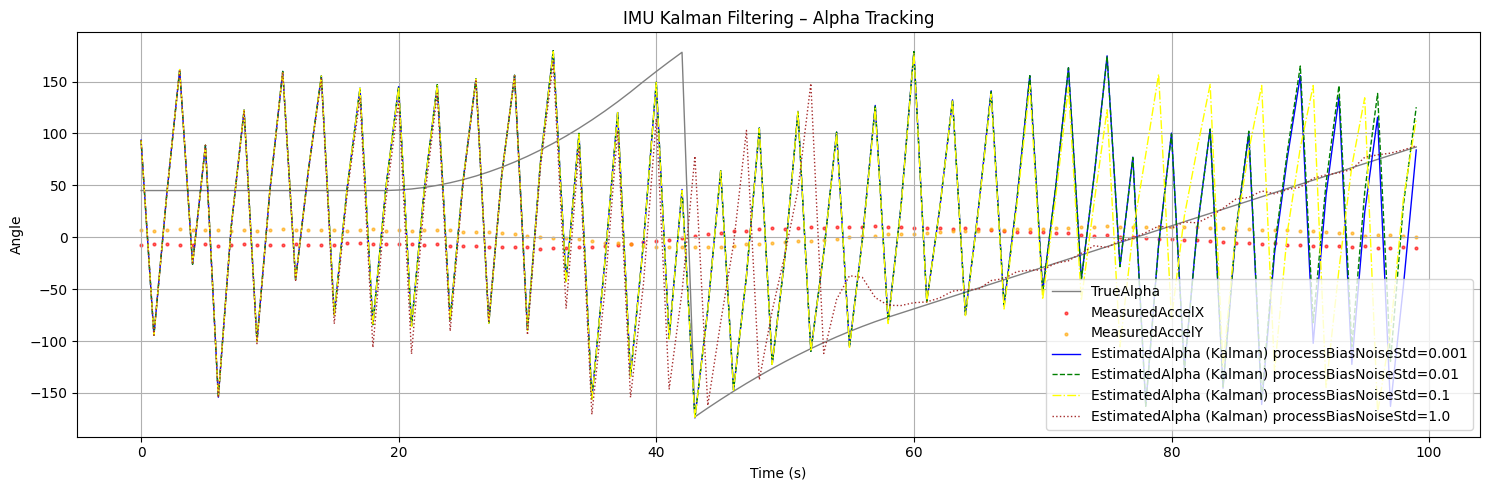

In [12]:
plt.figure(figsize=(15, 5))

plt.plot(TimeArray,
         TrueAlphaArray,
         label="TrueAlpha",
         color="grey",
         linewidth=1)

plt.scatter(TimeArray,
            MeasuredAccelXArray,
            label="MeasuredAccelX",
            color="red",
            s=4,
            alpha=0.6)

plt.scatter(TimeArray,
            MeasuredAccelYArray,
            label="MeasuredAccelY",
            color="orange",
            s=4,
            alpha=0.6)

for res, color, linestyle in zip(results, ["blue", "green", "yellow", "brown"], ['-', '--', '-.', ':']):
    plt.plot(TimeArray,
            res.estimatedAlphaArray,
             label="EstimatedAlpha (Kalman) "+res.label,
             linestyle = linestyle,
             color=color,
             linewidth=1)

plt.title("IMU Kalman Filtering – Alpha Tracking")
plt.xlabel("Time (s)")
plt.ylabel("Angle")

if doClip:
    plt.ylim(alphaMin, alphaMax)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

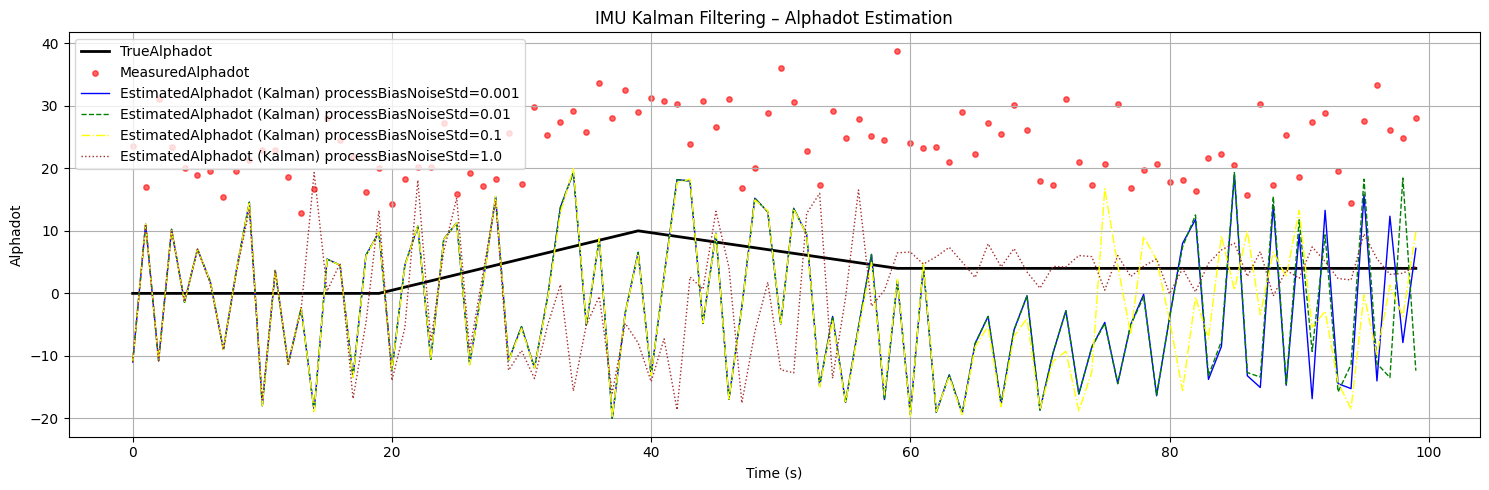

In [11]:
plt.figure(figsize=(15, 5))  # <<<

plt.plot(TimeArray,
         TrueAlphadotArray,
         label="TrueAlphadot",
         color="black",
         linewidth=2)  # <<<

plt.scatter(TimeArray,
            MeasuredAlphadotArray,
            label="MeasuredAlphadot",
            color="red",
            s=15,
            alpha=0.6)

for res, color, linestyle in zip(results, ["blue", "green", "yellow", "brown"], ["-", "--", "-.", ":"]):
    plt.plot(TimeArray,
            res.estimatedAlphadotArray,
             label="EstimatedAlphadot (Kalman) "+res.label,
             linestyle = linestyle,
             color=color,
             linewidth=1)


plt.title("IMU Kalman Filtering – Alphadot Estimation")  # <<<
plt.xlabel("Time (s)")
plt.ylabel("Alphadot")  # <<<

if doClip:
    plt.ylim(alphadotMin, alphadotMax)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

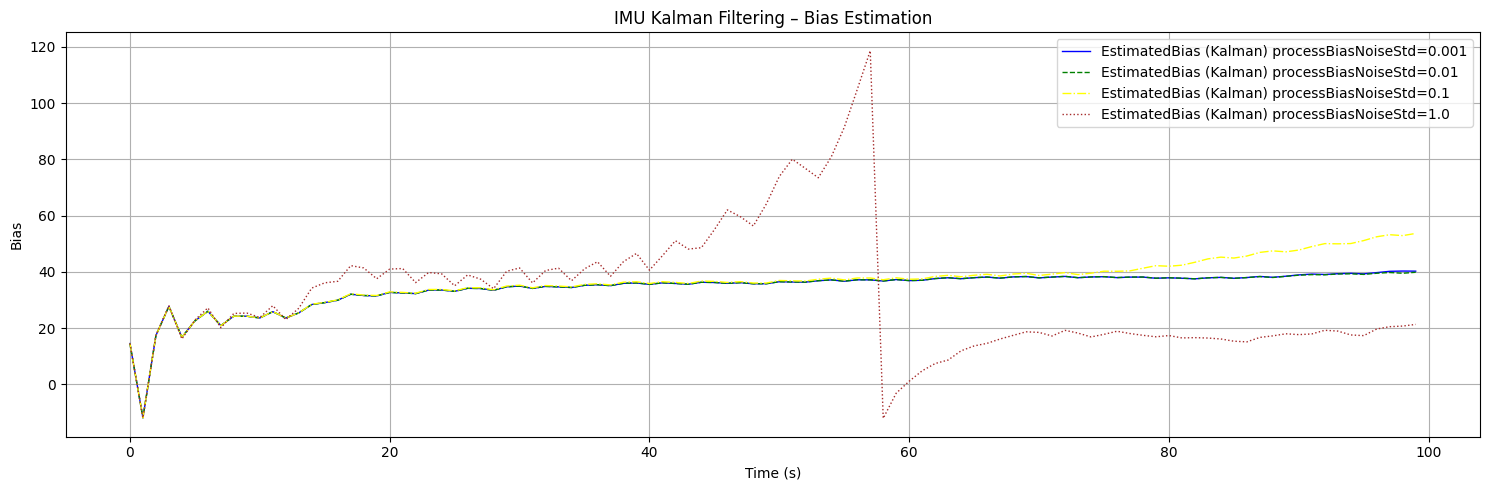

In [10]:
plt.figure(figsize=(15, 5))  # <<<

for res, color, linestyle in zip(results, ["blue", "green", "yellow", "brown"], ["-", "--", "-.", ":"]):
    plt.plot(TimeArray,
            res.estimatedBiasArray,
             label="EstimatedBias (Kalman) "+res.label,
             linestyle = linestyle,
             color=color,
             linewidth=1)


plt.title("IMU Kalman Filtering – Bias Estimation")  # <<<
plt.xlabel("Time (s)")
plt.ylabel("Bias")  # <<<

if doClip:
    plt.ylim(biasMin, biasMax)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()